# Baseline1: add_image_text_source_idx

## Stage1: [all] Split one-to-many mapping and Deal with Obfuscated data

<mark>Pay attention to the following block of `data_dir`<mark>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

# 输入数据路径
# data_dir = '../data/hateful_memes'
# data/DATA
# data_dir = "../data/DATA"
# data_dir =
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data
data_dir = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data"
# img_dir = os.path.join(data_dir, 'img')
# img_dir = os.path.join()
img_dir = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img"

/opt/anaconda3/envs/mlenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img
img_dir = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img"

# 定义支持的图片扩展名
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')

# 获取目录中的所有文件
all_files = os.listdir(img_dir)

# 筛选出图片文件
image_files = [file for file in all_files if file.lower().endswith(image_extensions)]

# 输出图片数量
print(f"Total Facebook Memes Detection: {len(image_files)} imgs")

Total Facebook Memes Detection: 10000 imgs


In [4]:
import os

splits = ['train', 'dev', 'test']
data_dir = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data"  # Replace with the actual data directory path

# "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data/train.jsonl"
# "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/all_data/train.jsonl"

df = []
for split in splits:
    file_path = os.path.join(data_dir, f'{split}.jsonl')
    print(f"Reading file: {file_path}")

    if not os.path.exists(file_path):
        print(f"File {file_path} does not exist.")
        continue
    
    if os.stat(file_path).st_size == 0:
        print(f"File {file_path} is empty.")
        continue

    try:
        split_df = pd.read_json(file_path, lines=True)
        split_df['split'] = split
        df.append(split_df)
    except ValueError as e:
        print(f"Error reading {file_path}: {e}")
        continue

# Concatenate dataframes
if df:
    df = pd.concat(df, axis=0, ignore_index=True)
    df['id'] = df['img'].str.split('/').str[1].str.split('.').str[0]
    df.index = df['id']
    df.index.name = None
    print(df.shape)
    # print(df.head())
else:
    print("No valid data to concatenate.")

df.head()

Reading file: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data/train.jsonl
Reading file: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data/dev.jsonl
Reading file: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/all_data/test.jsonl
(10000, 5)


,id,img,label,text,split
42953,42953,img/42953.png,0.0,its their character not their color that matters,train
23058,23058,img/23058.png,0.0,don't be afraid to love again everyone is not ...,train
13894,13894,img/13894.png,0.0,putting bows on your pet,train
37408,37408,img/37408.png,0.0,i love everything and everybody! except for sq...,train
82403,82403,img/82403.png,0.0,"everybody loves chocolate chip cookies, even h...",train


In [5]:
# 查看数据分布 (train / eval / test 占数量)
df['split'].value_counts()

split
train    8500
test     1000
dev       500
Name: count, dtype: int64

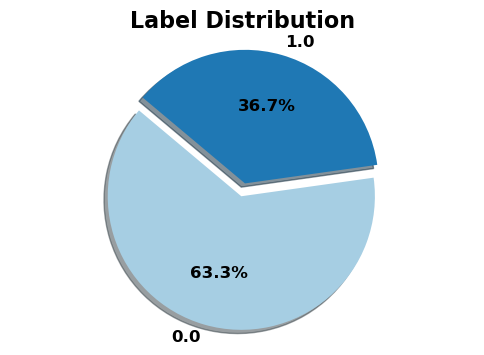

In [ ]:
### 这里可以添加可视化 "" ###
### 可做 ###
# 看原数据样本有没有失衡
# plot(piechat(df['label']))
import matplotlib.pyplot as plt

# Count the occurrences of each label in the 'label' column
label_counts = df['label'].value_counts()

# Define a color palette for the pie chart
colors = plt.cm.Paired(range(len(label_counts)))

# Explode the largest slice (optional)
explode = [0.1 if count == label_counts.max() else 0 for count in label_counts]

# Create the pie chart with enhanced aesthetics
plt.figure(figsize=(6, 4))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})

# Title with a larger font
plt.title('Label Distribution', fontsize=16, weight='bold')

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')  
plt.show()

In [7]:
df['text'].nunique()
# 检查到有重复的文本

8045

In [8]:
# 去重 (文本去重)
# 为每一句话，添加一个单独的 idx
idx_to_text = {idx:text for idx, text in enumerate(df['text'].unique())}
text_to_idx = {v:k for k, v in idx_to_text.items()}

# 增加新列: 新的idx标识
df['text_idx'] = df['text'].map(text_to_idx)
df.head()

,id,img,label,text,split,text_idx
42953,42953,img/42953.png,0.0,its their character not their color that matters,train,0
23058,23058,img/23058.png,0.0,don't be afraid to love again everyone is not ...,train,1
13894,13894,img/13894.png,0.0,putting bows on your pet,train,2
37408,37408,img/37408.png,0.0,i love everything and everybody! except for sq...,train,3
82403,82403,img/82403.png,0.0,"everybody loves chocolate chip cookies, even h...",train,4


- 出现这种情况，因为论文里面有提到，本数据集有一些 **混淆数据**，用同一段文字加在不同的图片上，就有不同的语义效果，所以元数据中，存有一部分是混淆数据。
- 混淆数据的展现在下面的可视化部分

/var/folders/nk/1w4w_4vj1q56j6rffdl50r_80000gn/T/ipykernel_55811/1068614031.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_100.values, y=top_100.index, palette="Blues_d")


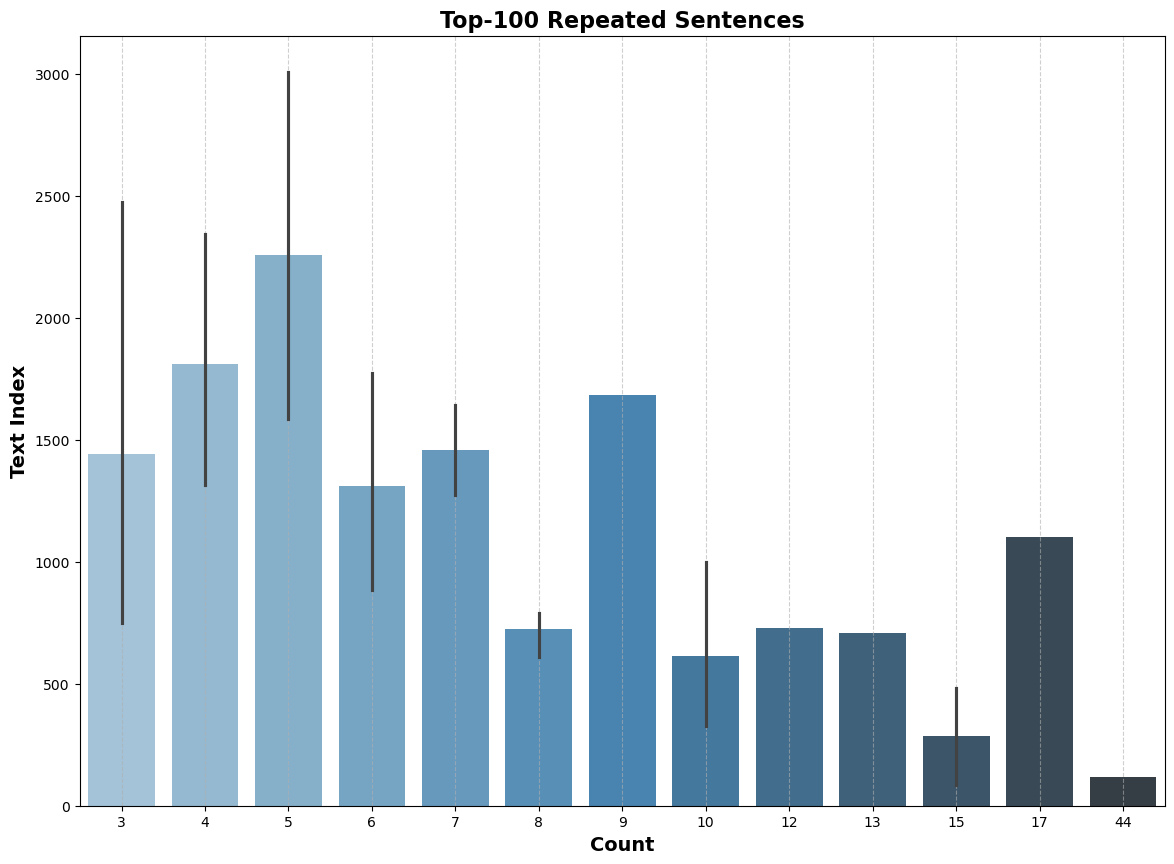

In [9]:
# 可视化，看 top-100 重复语句 (发现的确元数据有很多重复的) => 有一句重复高达40+
# df['text_idx'].value_counts()[:100].plot.bar(figsize=(30,8))
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each text index and select top-100
top_100 = df['text_idx'].value_counts()[:100]

# Create a more aesthetically pleasing horizontal bar plot
plt.figure(figsize=(14, 10))

# Use seaborn's barplot for a more polished look
sns.barplot(x=top_100.values, y=top_100.index, palette="Blues_d")

# Set labels and title with improved fonts
plt.xlabel('Count', fontsize=14, weight='bold')
plt.ylabel('Text Index', fontsize=14, weight='bold')
plt.title('Top-100 Repeated Sentences', fontsize=16, weight='bold')

# Add gridlines for better readability
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [10]:
# 实现了 "一对多映射" ：即一个文本内容可以对应多个图像
# num_txt idx < num_img
# 找到一个文本下 (单txt_idx) 下，对应的所有图像有这句话图像的 list(id)
# dict => txt_idx : [img_id1, img_id2]
text_idx_to_memes = df.groupby('text_idx')['id'].apply(list).to_dict()

# 字典筛选
text_idx_to_memes = {k:v for k, v in text_idx_to_memes.items() if len(v) > 1}

# 这里是输出: 存在一话多图多情况（output多少句话是有多张图的情况）
print(len(text_idx_to_memes)) # 1497

1497


In [11]:
# 此时，text_idx_to_memes 是 txt_idx : img_list 的字典组合

In [12]:
text_idx_to_label_to_memes = {}
# 在原来的基础上进行更新和删除
for text_idx, memes in text_idx_to_memes.items():
    text_idx_to_label_to_memes[text_idx] = {}
    text_idx_to_label_to_memes[text_idx]['non-hateful'] = []
    text_idx_to_label_to_memes[text_idx]['hateful'] = []

    hateful_added, non_hateful_added = False, False
    for meme_idx in memes:
        if df.loc[meme_idx]['label'] == 0:
            text_idx_to_label_to_memes[text_idx]['non-hateful'].append(meme_idx)
            non_hateful_added = True
        else:
            text_idx_to_label_to_memes[text_idx]['hateful'].append(meme_idx)
            hateful_added = True

    if not hateful_added or not non_hateful_added:
        del text_idx_to_label_to_memes[text_idx]

    # if len(text_idx_to_label_to_memes[text_idx]['non-hateful']) == 0:
    #     del text_idx_to_label_to_memes[text_idx]['non-hateful']
    # if len(text_idx_to_label_to_memes[text_idx]['hateful']) == 0:
        # del text_idx_to_label_to_memes[text_idx]['hateful']
        
print(len(text_idx_to_label_to_memes))

list(text_idx_to_label_to_memes.items())[:10]

1188


[(2, {'non-hateful': ['13894', '53027'], 'hateful': ['59817', '96180']}),
 (7, {'non-hateful': ['70914'], 'hateful': ['98531']}),
 (8, {'non-hateful': ['02973'], 'hateful': ['39785']}),
 (13, {'non-hateful': ['19324'], 'hateful': ['95278']}),
 (21, {'non-hateful': ['70146'], 'hateful': ['20497']}),
 (23, {'non-hateful': ['97180'], 'hateful': ['67801']}),
 (35, {'non-hateful': ['72598'], 'hateful': ['29587']}),
 (37, {'non-hateful': ['51846'], 'hateful': ['28396']}),
 (38, {'non-hateful': ['01569'], 'hateful': ['83579']}),
 (40, {'non-hateful': ['06418'], 'hateful': ['83152']})]

{'non-hateful': ['27401'], 'hateful': ['36872']}


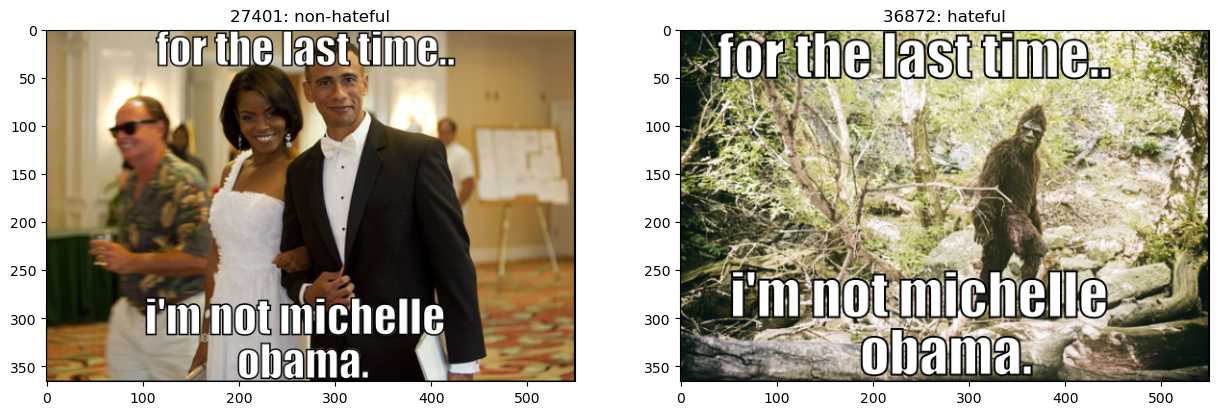

In [13]:
# 随机展示一组 “混淆数据”
sample_text_idx = np.random.choice(list(text_idx_to_label_to_memes.keys()))
print(text_idx_to_label_to_memes[sample_text_idx])
meme_idx_1 = np.random.choice(text_idx_to_label_to_memes[sample_text_idx]['non-hateful'])
meme_idx_2 = np.random.choice(text_idx_to_label_to_memes[sample_text_idx]['hateful'])

fig, axes = plt.subplots(1, 2, figsize=(15,10))
axes[0].imshow(Image.open(f'{img_dir}/{meme_idx_1}.png'))
axes[1].imshow(Image.open(f'{img_dir}/{meme_idx_2}.png'))
axes[0].set_title(f'{meme_idx_1}: non-hateful')
axes[1].set_title(f'{meme_idx_2}: hateful')
plt.show()
# end of stage1

---

## Stage2: [txt] Grouping similar sentences

In [14]:
! pip install spacy

In [15]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 968.5 kB/s  0:00:420:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [16]:
! pip install sentence-transformers

In [17]:
import spacy
from multiprocessing import Pool

nlp = spacy.load("en_core_web_md")

from sentence_transformers import SentenceTransformer

# 专门用于句子嵌入（Sentence Embedding）任务
model = SentenceTransformer('distilbert-base-nli-mean-tokens')

### Compute Sentence Meaning Similarity
- 这里可以 **后续** 改进 similarity 函数 (本base是基于简单的spcay可计算语义分数, 然后利用余弦相似度)

- 后续改进
> Sentence Transformer	对比学习训练的深层语义嵌入	高	通用、性能最佳，适用于几乎所有语义相似度任务。

> BERT/RoBERTa 分类	句对分类模型	极高（任务特定）	需要大量标注数据进行微调，适用于关系判断任务。

In [18]:
# 原始版本计算 similarity
def get_simlarity(text1, text2, method='spacy'):
    """
    src: https://stackoverflow.com/questions/65199011/is-there-a-way-to-check-similarity-between-two-full-sentences-in-python
    """
    # 低准确率
    if method == 'jaccard':
        text1 = set(text1.lower().split(" "))
        text2 = set(text2.lower().split(" "))
        score = len(text1.intersection(text2)) / len(text1.union(text2))
    elif method == 'spacy':
        embed1 = nlp(text1)
        embed2 = nlp(text2)
        score = embed1.similarity(embed2)
    else:
        raise ValueError

    return score

In [20]:
# # 按照 txt 划分字典结构，所以已经是去重
# meme_idx_to_text = df['text'].to_dict()
# meme_idxs = list(meme_idx_to_text.keys())
# scores = np.zeros((len(meme_idxs), len(meme_idxs)))

# # 全计算 (pair-wise的计算方式)
# # 计算复杂度: O^2
# # 出来一个matrix
# for i in tqdm(range(len(meme_idxs))):
#     for j in range(i+1, len(meme_idxs)):
#         text_i = meme_idx_to_text[meme_idxs[i]]
#         text_j = meme_idx_to_text[meme_idxs[j]]
#         score = get_simlarity(text_i, text_j, method='jaccard')
#         scores[i, j] = score
#         scores[j, i] = score

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

# 假设 `scores` 是你计算出的相似性矩阵
# meme_idx_to_text 和 meme_idxs 也已经定义好了
meme_idx_to_text = df['text'].to_dict()
meme_idxs = list(meme_idx_to_text.keys())
scores = np.zeros((len(meme_idxs), len(meme_idxs)))

# 全计算 (pair-wise的计算方式)
# 计算复杂度: O^2
# 出来一个matrix
for i in tqdm(range(len(meme_idxs))):
    for j in range(i+1, len(meme_idxs)):
        text_i = meme_idx_to_text[meme_idxs[i]]
        text_j = meme_idx_to_text[meme_idxs[j]]
        score = get_simlarity(text_i, text_j, method='jaccard')
        scores[i, j] = score
        scores[j, i] = score

100%|██████████| 10000/10000 [02:19<00:00, 71.77it/s] 


- Additional: 可补充可视化 (Similarity Score Heatmap / matrix)

In [ ]:
# 补充 Similarity Score Matrix 可视化 （半三角样式）
# insight: 可以观察到 "具有相似性" 的句子多不多，分不多不多 (如果heatmap中，大片都是暖红色，则是有大量相似语义的句子)

In [21]:
# 为了得出 encoder 默认的 embedding layers 参数值 (# 768)
sentences = list(meme_idx_to_text.values())
sentence_embeddings = model.encode(sentences)
print(sentence_embeddings.shape, type(sentence_embeddings))

(10000, 768) <class 'numpy.ndarray'>


In [22]:
# 计算余弦相似度
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
scores_tr = cosine_similarity(sentence_embeddings)

for i in range(len(scores_tr)):
    scores_tr[i, i] = 0
print(scores_tr.shape)

# 相似度分数 min / max
print(scores_tr.min(), scores_tr.max())

(10000, 10000)
-0.4053748 1.0000011


In [23]:
# 筛查出相似度分数较高的句子
# 自己设定阈值
# i_idxs / j_idxs = np.where((scores>0.7) & (scores_tr>0.7))# 相似度较高的 txt 句子标识 ids
i_idxs, j_idxs = np.where((scores>0.7) & (scores_tr>0.7))

print(len(i_idxs))
for i, j in zip(i_idxs[:5], j_idxs[:5]):
    print(meme_idxs[i], meme_idxs[j],  f'jaccard: {scores[i, j]}; tr: {scores_tr[i, j]}')
    print(meme_idx_to_text[meme_idxs[i]], '\n', meme_idx_to_text[meme_idxs[j]], '\n')

10518
13894 59817 jaccard: 1.0; tr: 1.0000001192092896
putting bows on your pet 
 putting bows on your pet 

13894 53027 jaccard: 1.0; tr: 1.0000001192092896
putting bows on your pet 
 putting bows on your pet 

13894 96180 jaccard: 1.0; tr: 1.0000001192092896
putting bows on your pet 
 putting bows on your pet 

70914 97623 jaccard: 0.8888888888888888; tr: 0.9987726211547852
tattoos are bad for your health i know 5 million people that had tattoos and they all died 
 tattoos are bad for your health i know 5 million people who had tattoos and they all died 

70914 98531 jaccard: 1.0; tr: 0.9999997615814209
tattoos are bad for your health i know 5 million people that had tattoos and they all died 
 tattoos are bad for your health i know 5 million people that had tattoos and they all died 



In [24]:
meme_idxs = list(meme_idx_to_text.keys())
psuedo_text_idx_to_meme_idxs = {}
for i, j in zip(i_idxs, j_idxs):
    for k in range(len(psuedo_text_idx_to_meme_idxs)):
        if meme_idxs[i] in psuedo_text_idx_to_meme_idxs[k] or meme_idxs[j] in psuedo_text_idx_to_meme_idxs[k]:
            psuedo_text_idx_to_meme_idxs[k].update({meme_idxs[i], meme_idxs[j]})
            break
    else:
        psuedo_text_idx_to_meme_idxs[len(psuedo_text_idx_to_meme_idxs)] = {meme_idxs[i], meme_idxs[j]}
print(len(psuedo_text_idx_to_meme_idxs))

1743


In [25]:
meme_idx_to_psuedo_text_idx = {}

for psuedo_text_idx, meme_idxs in psuedo_text_idx_to_meme_idxs.items():
    for meme_idx in meme_idxs:
        meme_idx_to_psuedo_text_idx[meme_idx] = psuedo_text_idx
print(len(meme_idx_to_psuedo_text_idx))

# for meme idxs that are not covered
non_covered_meme_idxs = set(df['id'].values) - set(meme_idx_to_psuedo_text_idx.keys())
for i, non_covered_meme_idx in enumerate(non_covered_meme_idxs, start=len(psuedo_text_idx_to_meme_idxs)):
    meme_idx_to_psuedo_text_idx[non_covered_meme_idx] = i
print(len(meme_idx_to_psuedo_text_idx))

4244
10000


In [26]:
df['pseudo_text_idx'] = df['id'].map(meme_idx_to_psuedo_text_idx)

In [27]:
df.head()

,id,img,label,text,split,text_idx,pseudo_text_idx
42953,42953,img/42953.png,0.0,its their character not their color that matters,train,0,2161
23058,23058,img/23058.png,0.0,don't be afraid to love again everyone is not ...,train,1,2931
13894,13894,img/13894.png,0.0,putting bows on your pet,train,2,0
37408,37408,img/37408.png,0.0,i love everything and everybody! except for sq...,train,3,3542
82403,82403,img/82403.png,0.0,"everybody loves chocolate chip cookies, even h...",train,4,4614


---

# Stage3: [img] Find Image index

- 这一part是专注于 "img" 的语义处理

In [28]:
! pip install imutils

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [29]:
from skimage.metrics import structural_similarity as compare_ssim
import imutils
import cv2

- basemodel: 这里用的是简单的 resnet 来提取特征 (feature_extractor)
    - idea: 这里后续可以 **改进特征的模型**

In [30]:
import torch
from torchvision.models import resnet18 

model = resnet18(pretrained=True)
model.eval()
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
x = torch.randn([1,3,224,224])

output = feature_extractor(x) 
# 只是位置知道 resnet18 的特征嵌入层的 shape
# 无实际意义
print(output.shape)

/opt/anaconda3/envs/mlenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/mlenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([1, 512, 1, 1])


- basemodel: 这里用的是最简单的图像处理pipeline，简单的resize，tott， norm
    - 后续或许可以改进 img_process pipeline: 提高分辨率？tag? entity? ROIs? ///

In [31]:
from PIL import Image
import torchvision.transforms as T

# 照片处理
transforms = T.Compose([T.Resize(224), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

imgs = []

# print()
# 全部进行处理
for img_fp in tqdm(df['img'].values.tolist()):
    # print(img_fp)
    # /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img
    img = Image.open(f'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/{img_fp}').convert('RGB').resize((224, 224))
    img = transforms(img).unsqueeze(dim=0)
    imgs.append(img)

100%|██████████| 10000/10000 [01:37<00:00, 103.08it/s]


In [32]:
# 得知处理后的 img_feature .shape
imgs = torch.cat(imgs, dim=0)
print(imgs.shape)

torch.Size([10000, 3, 224, 224])


In [33]:
batch_size = 100
assert len(imgs) % batch_size == 0
num_batches = len(imgs) // batch_size

# 容器
imgs_features = []

# 一个batch为一批次, 提取每个batch中，每张子图的特征 => 拼接
# ：批量（Batch-wise）提取图像特征，并将所有批次的特征拼接
for i in tqdm(range(num_batches)):
    start_idx = i*batch_size
    end_idx = start_idx + batch_size
    imgs_features_batch = feature_extractor(imgs[start_idx:end_idx])
    # 拼接，拉平
    # 转 np
    imgs_features_batch = imgs_features_batch.squeeze().detach().numpy()
    imgs_features.append(imgs_features_batch)
    
    
imgs_features = np.concatenate(imgs_features)
print(imgs_features.shape) # shape: (10000, 512) => (N, D)

100%|██████████| 100/100 [04:08<00:00,  2.48s/it]

(10000, 512)


In [ ]:
#

- embeddings similarity: tokens / img_embeddings 都可以计算 similarity 分数

In [34]:
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

# 
scores_img = cosine_similarity(imgs_features)

for i in range(len(scores_img)):
    scores_img[i, i] = 0
print(scores_img.shape)
print(scores_img.min(), scores_img.max())

(10000, 10000)
0.0 0.9994761


14556
42953 51683 scores_img: 0.9826449751853943
img/42953.png


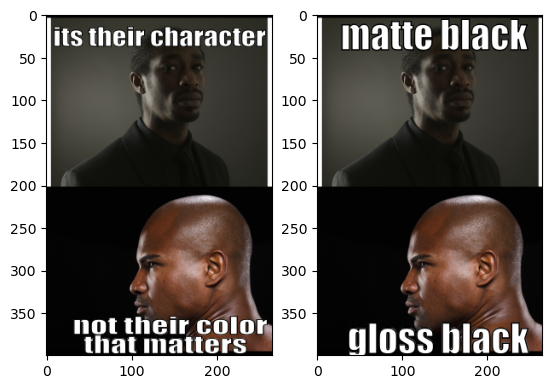

82403 71038 scores_img: 0.9235238432884216
img/82403.png


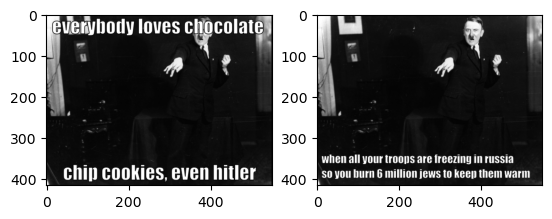

16952 92738 scores_img: 0.94631427526474
img/16952.png


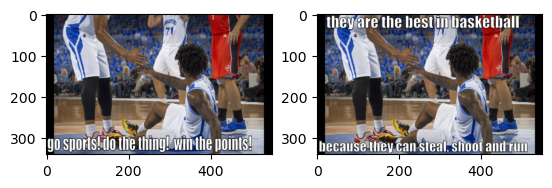

In [37]:
i_idxs, j_idxs = np.where((scores_img>0.92) & (scores_img<1))
print(len(i_idxs))
meme_idx_to_img = df['img'].to_dict()
meme_idxs = list(meme_idx_to_img.keys())
for i, j in zip(i_idxs[:3], j_idxs[:3]):
    print(meme_idxs[i], meme_idxs[j],  f'scores_img: {scores_img[i, j]}')
    fig, axes = plt.subplots(1, 2)
    print(meme_idx_to_img[meme_idxs[i]])
    axes[0].imshow(Image.open(f'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/{meme_idx_to_img[meme_idxs[i]]}'))
    axes[1].imshow(Image.open(f'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/{meme_idx_to_img[meme_idxs[j]]}'))
    plt.show()

- 一样的操作，和前面的 txt 层面找出 pseudo_txt_idx 一样：
    - 也是找出数据集中和该图片相似度最高的图片的 idx 做参照

In [38]:
# 照跑即可
# 一样的操作
meme_idxs = list(meme_idx_to_img.keys())
psuedo_img_idx_to_meme_idxs = {}
for i, j in zip(i_idxs, j_idxs):
    for k in range(len(psuedo_img_idx_to_meme_idxs)):
        if meme_idxs[i] in psuedo_img_idx_to_meme_idxs[k] or meme_idxs[j] in psuedo_img_idx_to_meme_idxs[k]:
            psuedo_img_idx_to_meme_idxs[k].update({meme_idxs[i], meme_idxs[j]})
            break
    else:
        psuedo_img_idx_to_meme_idxs[len(psuedo_img_idx_to_meme_idxs)] = {meme_idxs[i], meme_idxs[j]}
print(len(psuedo_img_idx_to_meme_idxs))

meme_idx_to_psuedo_img_idx = {}
for psuedo_img_idx, meme_idxs in psuedo_img_idx_to_meme_idxs.items():
    for meme_idx in meme_idxs:
        meme_idx_to_psuedo_img_idx[meme_idx] = psuedo_img_idx
print(len(meme_idx_to_psuedo_img_idx))

# for meme idxs that are not covered
non_covered_meme_idxs = set(df['id'].values) - set(meme_idx_to_psuedo_img_idx.keys())
for i, non_covered_meme_idx in enumerate(non_covered_meme_idxs, start=len(psuedo_img_idx_to_meme_idxs)):
    meme_idx_to_psuedo_img_idx[non_covered_meme_idx] = i
print(len(meme_idx_to_psuedo_img_idx))

1641
4289
10000


In [39]:
df['pseudo_img_idx'] = df['id'].map(meme_idx_to_psuedo_img_idx)

In [40]:
df.head()

,id,img,label,text,split,text_idx,pseudo_text_idx,pseudo_img_idx
42953,42953,img/42953.png,0.0,its their character not their color that matters,train,0,2161,0
23058,23058,img/23058.png,0.0,don't be afraid to love again everyone is not ...,train,1,2931,2816
13894,13894,img/13894.png,0.0,putting bows on your pet,train,2,0,5188
37408,37408,img/37408.png,0.0,i love everything and everybody! except for sq...,train,3,3542,3435
82403,82403,img/82403.png,0.0,"everybody loves chocolate chip cookies, even h...",train,4,4614,1


# Stage4: Save New CSV Data and Log Update
- 其实就是添加了4列:
    - split: 数据类型 (train / eval / test)
    - text_idx
    - pseudo_text_idx (定位另一个相似)
    - pseudo_img_idx (定位另一个相似)

In [42]:
# 这里的变量 "data_dir" 在第一个单元格里面设定
# print(data_dir)
file_path = f'{data_dir}/info.csv'
df.to_csv(file_path, index=False)

- 目标输出：

| id | img | label | text | split | text\_idx | pseudo\_text\_idx | pseudo\_img\_idx |
| :---: | :---: | :---: | :--- | :---: | :---: | :---: | :---: |
| 42953 | img/42953.png | 0 | its their character not their color that matters | train | 0 | 4901 | 0 |
| 23058 | img/23058.png | 0 | don't be afraid to love again everyone is not ... | train | 1 | 3620 | 3 |
| 413894 | img/13894.png | 0 | putting bows on your pet | train | 2 | 0395 | 6 |
| 37408 | img/37408.png | 0 | i love everything and everybody! except for sq... | train | 3 | 4451 | 4 |
| 382403 | img/82403.png | 0 | everybody loves chocolate chip cookies, even h... | train | 4 | 5609 | 1 |

In [44]:
# # Import the log_update function from the log_utils module
# from log_utils import log_update

# # Log an update after performing some task
# log_update(f"Downloaded the Facebook-HMD dataset and transform into CSV File: {file_path}")